# 서울 상권 분석 1단계: 상권 발견

**질문:** 현재 규모가 크거나 점포당 매출 효율이 높은 상권은 어디인가?

한국어 컬럼 버전의 전처리 데이터를 사용한다. 이번 단계에서는 설정한 기준 분기와 `한식음식점`을 기준으로 전체 순위와 동일 상권유형 내 위치를 살펴보고, 선택 상권 `강남역`의 핵심 지표를 확인한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import requests
from IPython.display import Markdown, display

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

data_dir = Path("C:/Users/SBA/Documents/SeSAC/seoul_commerce/data/analysis/korean")
reference_quarter = "20261"
reference_year, reference_quarter_number = divmod(int(reference_quarter), 10)
reference_period_label = f"{reference_year}년 {reference_quarter_number}분기"
selected_industry = "한식음식점"
selected_trade_area = "강남역"

In [2]:
analysis_columns = [
    "기준_년분기_코드", "상권_코드", "상권_명", "상권_구분_명", "자치구_명",
    "서비스_업종_명", "유사업종_점포_수", "분기_매출_금액", "분기_매출_건수",
    "분기_점포당_매출", "분기_점포당_매출_건수", "평균_객단가",
    "총_유동인구_수", "총_상주인구_수", "매출_전년동기_증감률",
    "점포_전년동기_증감률", "유동인구_전년동기_증감률", "수요_점포_전년동기_증감률_차이",
    "최근_4분기_매출_증가_횟수", "연속_매출_증가_분기_수", "핵심_분석_가능_여부",
]
commercial_df = pd.read_csv(
    data_dir / "상권_업종_분석데이터.csv",
    usecols=analysis_columns,
    dtype={"기준_년분기_코드": "string", "상권_코드": "string"},
    low_memory=False,
)
trade_area_df = pd.read_csv(
    data_dir / "상권_기준정보.csv",
    usecols=["상권_코드", "경도", "위도"],
    dtype={"상권_코드": "string"},
)

print(f"데이터 로드 완료: 상권·업종 {len(commercial_df):,}행, 상권 위치 {len(trade_area_df):,}행")

데이터 로드 완료: 상권·업종 92,749행, 상권 위치 1,650행


## 1. 분석 표본과 비교 기준

- 표본: 기준 분기·업종이 일치하고 `핵심_분석_가능_여부=True`인 상권
- 전체 순위: 같은 분기·업종의 모든 공식 상권유형을 함께 비교
- 동일유형 백분위: 같은 공식 상권유형 안에서 비교하며, 값이 100에 가까울수록 상위
- 동률 정렬: 현재 값 → 전년 동기 매출 증감률 → 상권 코드 순

### 파생변수 산식

- `총매출_전체_순위` = `분기_매출_금액`의 내림차순 순위
- `점포당매출_전체_순위` = `분기_점포당_매출`의 내림차순 순위
- `동일유형 백분위` = `(동일 상권유형 내 오름차순 순위 ÷ 동일유형 상권 수) × 100`
- `동일유형_비교_상권_수` = 같은 `상권_구분_명`에 속한 표본의 행 수

> `분기_매출_금액`, `분기_점포당_매출`, `매출_전년동기_증감률`은 전처리 데이터에서 그대로 불러온 지표이며 이 노트북에서 다시 계산하지 않는다.

In [3]:
sample_df = commercial_df.loc[
    commercial_df["기준_년분기_코드"].eq(reference_quarter)
    & commercial_df["서비스_업종_명"].eq(selected_industry)
    & commercial_df["핵심_분석_가능_여부"].eq(True)
].copy()
sample_df = sample_df.merge(trade_area_df, on="상권_코드", how="left")

sample_df["총매출_전체_순위"] = sample_df["분기_매출_금액"].rank(
    method="min", ascending=False
).astype("Int64")
sample_df["점포당매출_전체_순위"] = sample_df["분기_점포당_매출"].rank(
    method="min", ascending=False
).astype("Int64")
sample_df["총매출_동일유형_백분위"] = sample_df.groupby("상권_구분_명")["분기_매출_금액"].transform(
    lambda values: values.rank(pct=True) * 100
)
sample_df["점포당매출_동일유형_백분위"] = sample_df.groupby("상권_구분_명")["분기_점포당_매출"].transform(
    lambda values: values.rank(pct=True) * 100
)
sample_df["동일유형_비교_상권_수"] = sample_df.groupby("상권_구분_명")["상권_코드"].transform("size")

print(f"분석 조건: {reference_period_label} · {selected_industry} · {len(sample_df):,}개 상권")

분석 조건: 2026년 1분기 · 한식음식점 · 1,404개 상권


## 2. 규모와 효율 TOP10

총매출은 상권의 **시장 규모**, 점포당 매출은 개별 점포의 평균적인 **매출 효율 대리 지표**로 나누어 본다. TOP10은 각 지표의 내림차순 상위 10개이며, 동률이면 전년 동기 매출 증감률과 상권 코드 순으로 정렬한다.

In [4]:
def get_top_areas(data, metric):
    return data.sort_values(
        [metric, "매출_전년동기_증감률", "상권_코드"],
        ascending=[False, False, True],
        na_position="last",
    ).head(10).copy()

total_top_df = get_top_areas(sample_df, "분기_매출_금액")
efficiency_top_df = get_top_areas(sample_df, "분기_점포당_매출")

total_top_table = total_top_df[["상권_명", "상권_구분_명", "자치구_명", "분기_매출_금액", "매출_전년동기_증감률"]].copy()
total_top_table["분기 매출(억원)"] = (total_top_table.pop("분기_매출_금액") / 100_000_000).round(1)
total_top_table["전년 동기 증감률(%)"] = total_top_table.pop("매출_전년동기_증감률").round(1)

efficiency_top_table = efficiency_top_df[["상권_명", "상권_구분_명", "자치구_명", "분기_점포당_매출", "매출_전년동기_증감률"]].copy()
efficiency_top_table["점포당 매출(백만원)"] = (efficiency_top_table.pop("분기_점포당_매출") / 1_000_000).round(1)
efficiency_top_table["전년 동기 증감률(%)"] = efficiency_top_table.pop("매출_전년동기_증감률").round(1)

display(Markdown("#### 총매출 TOP10"), total_top_table.reset_index(drop=True))
display(Markdown("#### 점포당 매출 TOP10"), efficiency_top_table.reset_index(drop=True))

#### 총매출 TOP10

,상권_명,상권_구분_명,자치구_명,분기 매출(억원),전년 동기 증감률(%)
0,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,"1,106.60",4.80
1,강남역,발달상권,서초구,604.30,7.10
2,여의도역(여의도),발달상권,영등포구,543.00,-4.80
3,종로·청계 관광특구,관광특구,종로구,466.80,3.60
4,북창동(시청역_6번),발달상권,중구,439.40,-5.60
5,잠실 관광특구,관광특구,송파구,401.30,28.40
6,종각역,발달상권,종로구,390.00,12.40
7,가산디지털단지,발달상권,금천구,380.30,6.40
8,역삼역,발달상권,강남구,372.50,4.60
9,종로3가역,발달상권,종로구,368.90,5.30


#### 점포당 매출 TOP10

,상권_명,상권_구분_명,자치구_명,점포당 매출(백만원),전년 동기 증감률(%)
0,삼성중앙역 5번,골목상권,강남구,"1,171.70",5.70
1,신구중학교,골목상권,강남구,701.10,33.70
2,봉원사,골목상권,서대문구,471.40,8.00
3,천호태영아파트,골목상권,강동구,437.20,28.90
4,북창동(시청역_6번),발달상권,중구,395.90,-5.60
5,문래역 3번,골목상권,영등포구,377.00,-9.20
6,갈산공원,골목상권,양천구,305.50,18.50
7,한국상담대학원대학교,골목상권,서초구,247.80,-7.90
8,동구여중,골목상권,성북구,242.60,20.80
9,방아다리근린공원(횃불트리니티신학대학원대학교),골목상권,서초구,241.30,-5.20


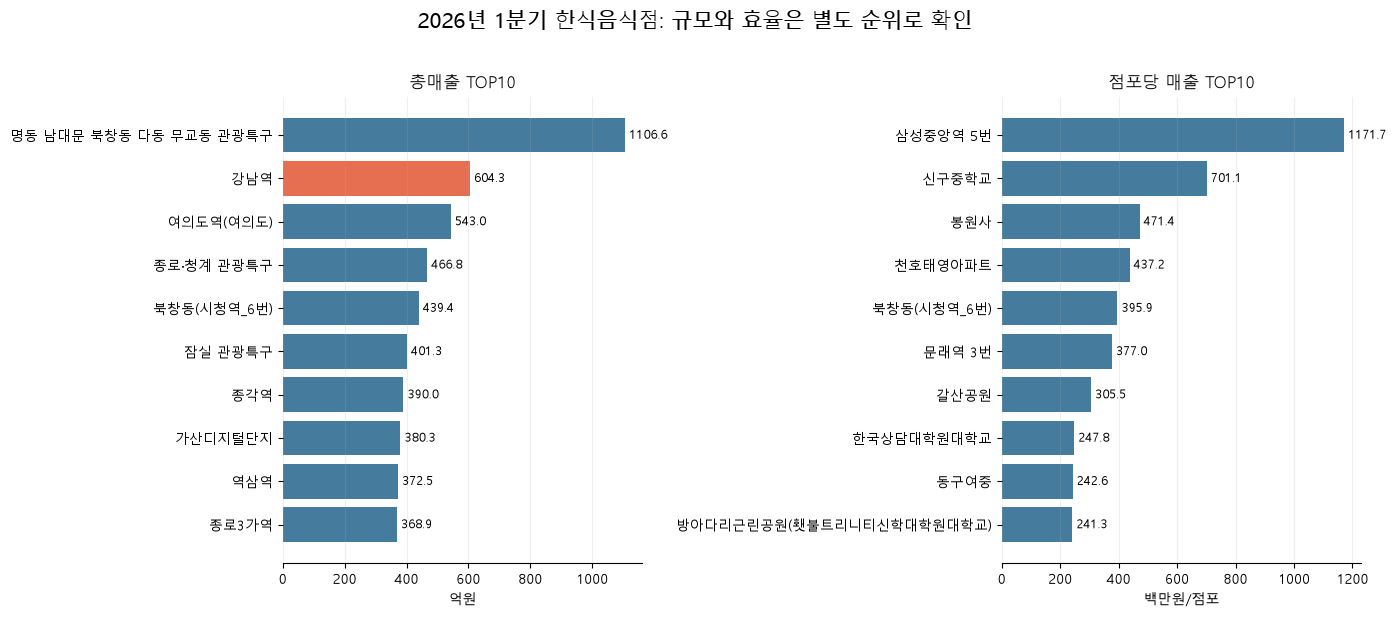

In [5]:
def plot_ranking(ax, data, metric, scale, title, unit):
    plot_df = data.iloc[::-1]
    values = plot_df[metric] / scale
    colors = ["#E76F51" if name == selected_trade_area else "#457B9D" for name in plot_df["상권_명"]]
    bars = ax.barh(plot_df["상권_명"], values, color=colors)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right", "left"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_ranking(axes[0], total_top_df, "분기_매출_금액", 100_000_000, "총매출 TOP10", "억원")
plot_ranking(axes[1], efficiency_top_df, "분기_점포당_매출", 1_000_000, "점포당 매출 TOP10", "백만원/점포")
fig.suptitle(f"{reference_period_label} {selected_industry}: 규모와 효율은 별도 순위로 확인", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 3. 실제 지도에서 본 상권 분포

밝은 지도 배경 위에 서울·자치구 경계와 자치구명을 함께 표시한다. 점 크기는 총매출 규모, 색상은 공식 상권유형을 나타내며 마우스를 올리면 상권별 핵심 지표를 확인할 수 있다. 강남역은 붉은색으로 강조한다.

> 경계 출처: [southkorea/seoul-maps](https://github.com/southkorea/seoul-maps) · JUSO 2015 · Apache 2.0

In [6]:
map_df = sample_df.dropna(subset=["경도", "위도"]).copy()
map_df["분기 매출(억원)"] = map_df["분기_매출_금액"] / 100_000_000
map_df["점포당 매출(백만원)"] = map_df["분기_점포당_매출"] / 1_000_000
boundary_url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/juso/2015/json/seoul_municipalities_geo_simple.json"
boundary_response = requests.get(boundary_url, timeout=30)
boundary_response.raise_for_status()
seoul_boundary = boundary_response.json()
district_names = [feature["properties"]["SIG_KOR_NM"] for feature in seoul_boundary["features"]]
district_labels = map_df.groupby("자치구_명", as_index=False)[["경도", "위도"]].median()
selected_point = map_df.loc[map_df["상권_명"].eq(selected_trade_area)].iloc[0]

map_fig = px.scatter_map(
    map_df,
    lat="위도",
    lon="경도",
    color="상권_구분_명",
    size="분기_매출_금액",
    size_max=28,
    hover_name="상권_명",
    hover_data={
        "자치구_명": True,
        "상권_구분_명": True,
        "분기 매출(억원)": ":,.1f",
        "점포당 매출(백만원)": ":,.1f",
        "유사업종_점포_수": ":,.0f",
        "분기_매출_금액": False,
        "위도": False,
        "경도": False,
    },
    labels={
        "상권_구분_명": "상권유형",
        "자치구_명": "자치구",
        "유사업종_점포_수": "유사업종 점포 수",
    },
    center={"lat": map_df["위도"].mean(), "lon": map_df["경도"].mean()},
    zoom=9.5,
    height=700,
    opacity=0.82,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
map_fig.add_trace(
    go.Choroplethmap(
        geojson=seoul_boundary,
        locations=district_names,
        z=[0] * len(district_names),
        featureidkey="properties.SIG_KOR_NM",
        colorscale=[[0, "rgba(255,255,255,0)"], [1, "rgba(255,255,255,0)"]],
        zmin=0,
        zmax=1,
        showscale=False,
        marker={"line": {"color": "#64748B", "width": 1.4}},
        hoverinfo="skip",
        showlegend=False,
        name="서울 자치구 경계",
    )
)
map_fig.add_trace(
    go.Scattermap(
        lat=district_labels["위도"],
        lon=district_labels["경도"],
        mode="text",
        text=district_labels["자치구_명"],
        textfont={"size": 11, "color": "#334155"},
        hoverinfo="skip",
        showlegend=False,
        name="자치구명",
    )
)
map_fig.add_trace(
    go.Scattermap(
        lat=[selected_point["위도"]],
        lon=[selected_point["경도"]],
        mode="markers+text",
        marker={"size": 26, "color": "#D62828", "opacity": 1.0},
        text=[selected_trade_area],
        textposition="top right",
        textfont={"size": 15, "color": "#B91C1C"},
        below="",
        name=selected_trade_area,
        hovertemplate=(
            f"<b>{selected_trade_area}</b><br>"
            f"분기 매출: {selected_point['분기 매출(억원)']:,.1f}억원<br>"
            f"점포당 매출: {selected_point['점포당 매출(백만원)']:,.1f}백만원<extra></extra>"
        ),
    )
)
map_fig.update_layout(
    title={"text": f"{reference_period_label} {selected_industry} 상권 위치와 총매출 규모", "x": 0.5},
    map_style="carto-positron",
    legend_title_text="상권유형",
    margin={"l": 0, "r": 0, "t": 60, "b": 0},
)
map_fig.show()

## 4. 선택 상권: 강남역

전체 상권 순위와 같은 공식 상권유형 안의 백분위를 함께 확인한다.

In [7]:
selected_row = sample_df.loc[sample_df["상권_명"].eq(selected_trade_area)].iloc[0]
volume_rank = int(selected_row["총매출_전체_순위"])
efficiency_rank = int(selected_row["점포당매출_전체_순위"])
peer_count = int(selected_row["동일유형_비교_상권_수"])
growth_rate = selected_row["매출_전년동기_증감률"]
growth_label = f"{growth_rate:,.1f}%" if pd.notna(growth_rate) else "계산 불가"

summary_df = pd.DataFrame({
    "지표": [
        "상권유형 / 자치구", "분기 매출", "유사업종 점포 수", "점포당 분기 매출",
        "총 유동인구", "총 상주인구", "매출 전년 동기 증감률",
        "최근 4분기 매출 증가 횟수", "연속 매출 증가 분기 수",
        "총매출 전체 순위", "점포당 매출 전체 순위",
        "총매출 동일유형 백분위", "점포당 매출 동일유형 백분위",
    ],
    "값": [
        f"{selected_row['상권_구분_명']} / {selected_row['자치구_명']}",
        f"{selected_row['분기_매출_금액'] / 100_000_000:,.1f}억원",
        f"{selected_row['유사업종_점포_수']:,.0f}개",
        f"{selected_row['분기_점포당_매출'] / 1_000_000:,.1f}백만원/점포",
        f"{selected_row['총_유동인구_수']:,.0f}명",
        f"{selected_row['총_상주인구_수']:,.0f}명",
        growth_label,
        f"{selected_row['최근_4분기_매출_증가_횟수']:,.0f}회",
        f"{selected_row['연속_매출_증가_분기_수']:,.0f}분기",
        f"{volume_rank}위 / {len(sample_df):,}개",
        f"{efficiency_rank}위 / {len(sample_df):,}개",
        f"{selected_row['총매출_동일유형_백분위']:,.1f} / 100 ({peer_count}개 비교)",
        f"{selected_row['점포당매출_동일유형_백분위']:,.1f} / 100 ({peer_count}개 비교)",
    ],
})
display(summary_df)

growth_direction = "증가" if pd.notna(growth_rate) and growth_rate >= 0 else "감소"
display(Markdown(
    f"""### 1단계 해석
- **규모:** 강남역은 총매출 기준 전체 {len(sample_df):,}개 상권 중 **{volume_rank}위**, 동일 `{selected_row['상권_구분_명']}` 내 **{selected_row['총매출_동일유형_백분위']:.1f}백분위**다.
- **효율:** 점포당 매출 기준 전체 **{efficiency_rank}위**, 동일 유형 내 **{selected_row['점포당매출_동일유형_백분위']:.1f}백분위**다.
- **변화:** 전년 동기 대비 매출은 **{growth_label} {growth_direction}**했다. 성장의 원인은 다음 단계에서 점포 수·거래 건수·객단가로 나누어 살펴본다.

> TOP10과 백분위는 탐색용 비교 결과이며, 비용·수익성·개별 점포 차이를 반영한 출점 추천은 아니다."""
))

,지표,값
0,상권유형 / 자치구,발달상권 / 서초구
1,분기 매출,604.3억원
2,유사업종 점포 수,489개
3,점포당 분기 매출,123.6백만원/점포
4,총 유동인구,"7,710,017명"
5,총 상주인구,"6,248명"
6,매출 전년 동기 증감률,7.1%
7,최근 4분기 매출 증가 횟수,2회
8,연속 매출 증가 분기 수,0분기
9,총매출 전체 순위,"2위 / 1,404개"


### 1단계 해석
- **규모:** 강남역은 총매출 기준 전체 1,404개 상권 중 **2위**, 동일 `발달상권` 내 **100.0백분위**다.
- **효율:** 점포당 매출 기준 전체 **101위**, 동일 유형 내 **86.2백분위**다.
- **변화:** 전년 동기 대비 매출은 **7.1% 증가**했다. 성장의 원인은 다음 단계에서 점포 수·거래 건수·객단가로 나누어 살펴본다.

> TOP10과 백분위는 탐색용 비교 결과이며, 비용·수익성·개별 점포 차이를 반영한 출점 추천은 아니다.

# 서울 상권 분석 2단계: 매출 성장 요인 분석

선택 상권·업종의 매출 변화를 **점포 수, 점포당 거래건수, 평균 객단가**로 나누고 최근 8분기의 방향과 지속성을 확인한다.

- 분석 대상: 핵심_분석_가능_여부가 True인 선택 상권·업종
- 성장 비교: 선택 기준분기와 전년 동기
- 추세 범위: 선택 기준분기까지 최근 8분기

## 분석용 파생변수 산식

총매출을 **점포 수 × 점포당 거래건수 × 평균 객단가**로 보고 다음 값을 계산한다.

- **점포 수 기여도** = 100 × ln(기준분기 점포 수 / 전년 동기 점포 수)
- **거래량 기여도** = 100 × ln(기준분기 점포당 거래건수 / 전년 동기 점포당 거래건수)
- **객단가 기여도** = 100 × ln(기준분기 평균 객단가 / 전년 동기 평균 객단가)
- 세 기여도의 합은 **총매출 로그 변화량** 100 × ln(기준분기 총매출 / 전년 동기 총매출)과 같다.
> **포인트:** 100 × 로그 변화량을 읽기 쉽게 나타낸 값으로, 변화가 작을 때는 일반 증감률(%)과 비슷하다.
- **분기 추세율** = 최근 8분기 로그 매출의 분기 순서 회귀기울기 b를 100 × (exp(b) - 1)로 변환한 값
- **전년 동기 증감률 변동성** = 최근 8분기 매출 전년 동기 증감률의 표준편차
- 총매출이 증가했을 때 양(+)의 기여 요인이 하나면 해당 요인 성장형, 둘 이상이면 동반 성장형으로 구분한다.

In [8]:
prior_year_quarter = f"{reference_year - 1}{reference_quarter_number}"
growth_df = commercial_df.loc[
    commercial_df["상권_명"].eq(selected_trade_area)
    & commercial_df["서비스_업종_명"].eq(selected_industry)
    & commercial_df["핵심_분석_가능_여부"].eq(True)
    & commercial_df["기준_년분기_코드"].le(reference_quarter)
].sort_values("기준_년분기_코드")

trend_df = growth_df.tail(8).copy()
trend_df["분기_표시"] = [
    f"{value[:4]}년 {int(value[-1])}분기" for value in trend_df["기준_년분기_코드"]
]
period_rows = growth_df.set_index("기준_년분기_코드")
current_row = period_rows.loc[reference_quarter]
previous_row = period_rows.loc[prior_year_quarter]

factor_columns = ["유사업종_점포_수", "분기_점포당_매출_건수", "평균_객단가"]
factor_labels = ["점포 수", "점포당 거래건수", "평균 객단가"]
log_contributions = 100 * np.log(
    current_row[factor_columns].to_numpy(dtype=float)
    / previous_row[factor_columns].to_numpy(dtype=float)
)
contribution_df = pd.DataFrame({"성장 요인": factor_labels, "로그 성장 기여도": log_contributions})
total_log_change = 100 * np.log(current_row["분기_매출_금액"] / previous_row["분기_매출_금액"])

positive_drivers = contribution_df.loc[contribution_df["로그 성장 기여도"].gt(0), "성장 요인"]
single_growth_types = {"점포 수": "점포 확장형", "점포당 거래건수": "거래량 성장형", "평균 객단가": "객단가 성장형"}
if total_log_change <= 0:
    growth_type = "감소·정체형"
elif len(positive_drivers) == 1:
    growth_type = single_growth_types[positive_drivers.iloc[0]]
else:
    growth_type = "동반 성장형"

trend_slope = np.polyfit(np.arange(len(trend_df)), np.log(trend_df["분기_매출_금액"]), 1)[0]
quarterly_trend_rate = 100 * np.expm1(trend_slope)
yoy_volatility = trend_df["매출_전년동기_증감률"].std(ddof=0)

,지표,값,단위
0,매출 전년 동기 증감률,7.1,%
1,점포 수 성장 기여도,2.5,포인트
2,점포당 거래건수 성장 기여도,6.2,포인트
3,평균 객단가 성장 기여도,-1.8,포인트
4,총매출 로그 변화,6.8,포인트
5,최근 8분기 분기 추세율,1.0,%/분기
6,전년 동기 증감률 변동성,3.7,%p
7,최근 4분기 매출 증가 횟수,2.0,회
8,연속 매출 증가 분기 수,0.0,분기


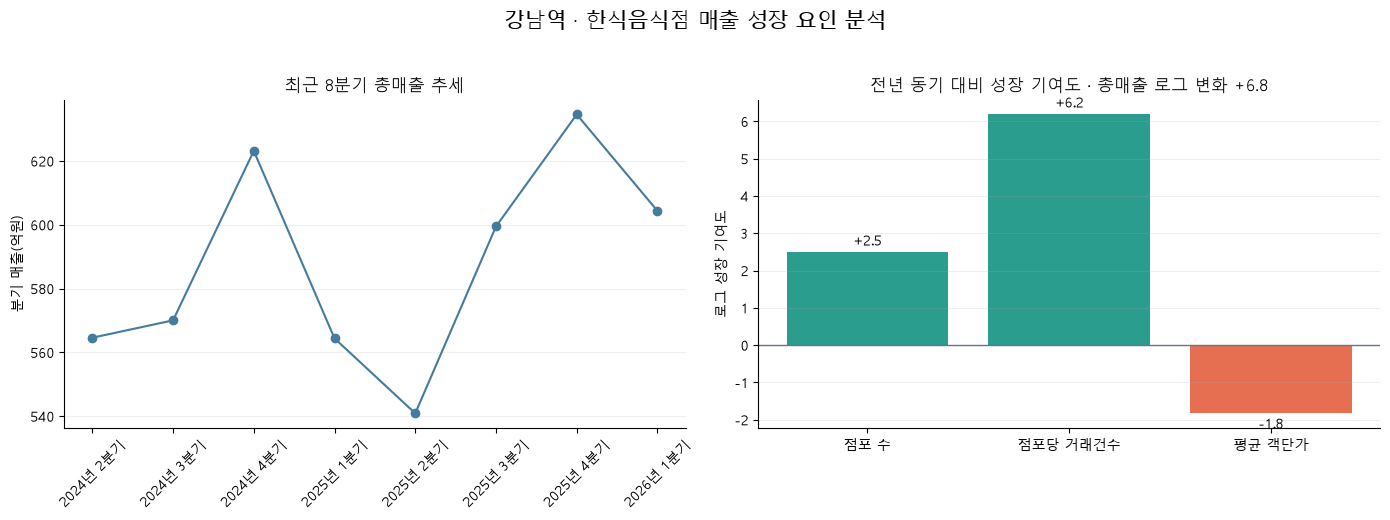

### 2단계 해석
- **성장 내용:** 2026년 1분기 총매출은 전년 동기보다 **+7.1%** 변했고, 분류 결과는 **동반 성장형**이다.
- **기여 요인:** 점포 수 +2.5, 점포당 거래건수 +6.2, 평균 객단가 -1.8이며, 변화 폭이 가장 큰 요인은 **점포당 거래건수**이다.
- **8분기 흐름:** 로그 매출 추세는 분기당 **1.0% 상승** 방향이며, 전년 동기 증감률 변동성은 **3.7%p**다.
- **지속성:** 최근 4분기 중 매출 증가 분기는 **2회**, 현재 연속 증가 기간은 **0분기**다.

> 성장 기여도는 양수 값의 로그 변화에서 정확히 합산되는 분해 결과다. 추정매출의 변화 구조를 설명하며 개별 점포의 실제 성장이나 향후 지속을 보장하지 않는다.

In [9]:
numeric_result_df = pd.DataFrame([
    ("매출 전년 동기 증감률", current_row["매출_전년동기_증감률"], "%"),
    *[(f"{label} 성장 기여도", value, "포인트") for label, value in zip(factor_labels, log_contributions)],
    ("총매출 로그 변화", total_log_change, "포인트"),
    ("최근 8분기 분기 추세율", quarterly_trend_rate, "%/분기"),
    ("전년 동기 증감률 변동성", yoy_volatility, "%p"),
    ("최근 4분기 매출 증가 횟수", current_row["최근_4분기_매출_증가_횟수"], "회"),
    ("연속 매출 증가 분기 수", current_row["연속_매출_증가_분기_수"], "분기"),
], columns=["지표", "값", "단위"])
display(numeric_result_df.style.format({"값": "{:,.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(trend_df["분기_표시"], trend_df["분기_매출_금액"] / 100_000_000, marker="o", color="#457B9D")
axes[0].set(title="최근 8분기 총매출 추세", ylabel="분기 매출(억원)")
axes[0].tick_params(axis="x", rotation=45)

colors = np.where(contribution_df["로그 성장 기여도"].ge(0), "#2A9D8F", "#E76F51")
bars = axes[1].bar(contribution_df["성장 요인"], contribution_df["로그 성장 기여도"], color=colors)
axes[1].bar_label(bars, fmt="%+.1f", padding=3)
axes[1].axhline(0, color="#64748B", linewidth=1)
axes[1].set(
    title=f"전년 동기 대비 성장 기여도 · 총매출 로그 변화 {total_log_change:+.1f}",
    ylabel="로그 성장 기여도",
)
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"{selected_trade_area} · {selected_industry} 매출 성장 요인 분석", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

sales_yoy_rate = current_row["매출_전년동기_증감률"]
recent_growth_count = int(current_row["최근_4분기_매출_증가_횟수"])
consecutive_growth_quarters = int(current_row["연속_매출_증가_분기_수"])
main_driver = contribution_df.loc[contribution_df["로그 성장 기여도"].abs().idxmax(), "성장 요인"]
contribution_text = ", ".join(
    f"{row['성장 요인']} {row['로그 성장 기여도']:+.1f}"
    for _, row in contribution_df.iterrows()
)
trend_direction = "상승" if quarterly_trend_rate >= 0 else "하락"
display(Markdown(
    f"""### 2단계 해석
- **성장 내용:** {reference_period_label} 총매출은 전년 동기보다 **{sales_yoy_rate:+.1f}%** 변했고, 분류 결과는 **{growth_type}**이다.
- **기여 요인:** {contribution_text}이며, 변화 폭이 가장 큰 요인은 **{main_driver}**이다.
- **8분기 흐름:** 로그 매출 추세는 분기당 **{abs(quarterly_trend_rate):.1f}% {trend_direction}** 방향이며, 전년 동기 증감률 변동성은 **{yoy_volatility:.1f}%p**다.
- **지속성:** 최근 4분기 중 매출 증가 분기는 **{recent_growth_count}회**, 현재 연속 증가 기간은 **{consecutive_growth_quarters}분기**다.

> 성장 기여도는 양수 값의 로그 변화에서 정확히 합산되는 분해 결과다. 추정매출의 변화 구조를 설명하며 개별 점포의 실제 성장이나 향후 지속을 보장하지 않는다."""
))

# 서울 상권 분석 3단계: 방문과 소비 구성 비교

선택 상권·업종에서 **유동인구 증가가 점포 증가를 앞섰는지**, 방문자 구성이 실제 매출 구성과 얼마나 비슷한지 확인한다.

## 분석용 파생변수 산식

- **수요–점포 성장 격차(G)** = 유동인구 전년 동기 증감률 - 점포 수 전년 동기 증감률 (%p)
  - 양수이면 유동인구가, 음수이면 점포 수가 상대적으로 더 빠르게 증가했다.
- **구성 차이 지수(T)** = 1/2 × Σ|매출 비중 - 유동인구 비중|
  - 0에 가까울수록 두 구성이 비슷하며, 1에 가까울수록 차이가 크다.
- **매출 과대표 비율(R)** = 매출 비중 / 유동인구 비중 (유동인구 비중 > 0인 항목만 계산)
  - 1보다 크면 해당 항목의 매출 비중이 유동인구 비중보다 높다.

> 매출 과대표 비율은 구성비 비교 지표이며, 방문자가 실제 구매한 비율을 뜻하는 전환율은 아니다.

In [10]:
comparison_columns = [
    "기준_년분기_코드", "상권_명", "서비스_업종_명", "구성_유형", "구성_명",
    "구성_순서", "매출_금액_비중", "유동인구_비중", "매출_금액_커버리지",
    "구성비_비교_가능_여부", "매출_유동인구_비중_차이", "매출_유동인구_비중_비율",
]
comparison_parts = []
for chunk in pd.read_csv(
    data_dir / "구성비_비교데이터.csv", usecols=comparison_columns,
    dtype={"기준_년분기_코드": "string"}, chunksize=200_000, low_memory=False,
):
    mask = (
        chunk["기준_년분기_코드"].eq(reference_quarter)
        & chunk["상권_명"].eq(selected_trade_area)
        & chunk["서비스_업종_명"].eq(selected_industry)
        & chunk["구성비_비교_가능_여부"].eq(True)
    )
    comparison_parts.append(chunk.loc[mask])

composition_df = pd.concat(comparison_parts, ignore_index=True)
composition_labels = {"gender": "성별", "age": "연령", "weekday": "요일", "time_band": "시간대"}
composition_order = list(composition_labels.values())
composition_df["구성 기준"] = composition_df["구성_유형"].map(composition_labels)

distance_df = (
    composition_df.groupby("구성 기준")["매출_유동인구_비중_차이"].apply(lambda values: values.abs().sum() / 2)
    .reindex(composition_order).rename("구성 차이 지수").reset_index()
)
coverage_df = (
    composition_df.groupby("구성 기준")["매출_금액_커버리지"].first()
    .reindex(composition_order).mul(100).rename("매출액 구성비 커버리지(%)").reset_index()
)
composition_result_df = distance_df.merge(coverage_df, on="구성 기준")
top_ratio_df = composition_df.nlargest(8, "매출_유동인구_비중_비율").copy()

selected_commercial_row = commercial_df.loc[
    commercial_df["기준_년분기_코드"].eq(reference_quarter)
    & commercial_df["상권_명"].eq(selected_trade_area)
    & commercial_df["서비스_업종_명"].eq(selected_industry)
].iloc[0]


### 수치 결과

,지표,값,단위
0,유동인구 전년 동기 증감률,-2.0,%
1,점포 수 전년 동기 증감률,2.5,%
2,수요–점포 성장 격차,-4.5,%p


,구성 기준,구성 차이 지수,매출액 구성비 커버리지(%)
0,성별,0.091,81.8
1,연령,0.134,81.8
2,요일,0.080,100.0
3,시간대,0.354,100.0


#### 매출 과대표 비율 상위 항목

,구성 기준,구성 항목,매출 비중(%),유동인구 비중(%),매출 과대표 비율
20,시간대,21~24시,24.2,9.8,2.48
19,시간대,17~21시,39.4,22.4,1.76
4,연령,30대,36.9,25.9,1.42
13,요일,토요일,17.2,12.6,1.36
17,시간대,11~14시,22.4,18.4,1.22
6,연령,50대,13.3,11.1,1.20
0,성별,남성,58.0,48.9,1.19
12,요일,금요일,19.6,16.5,1.18


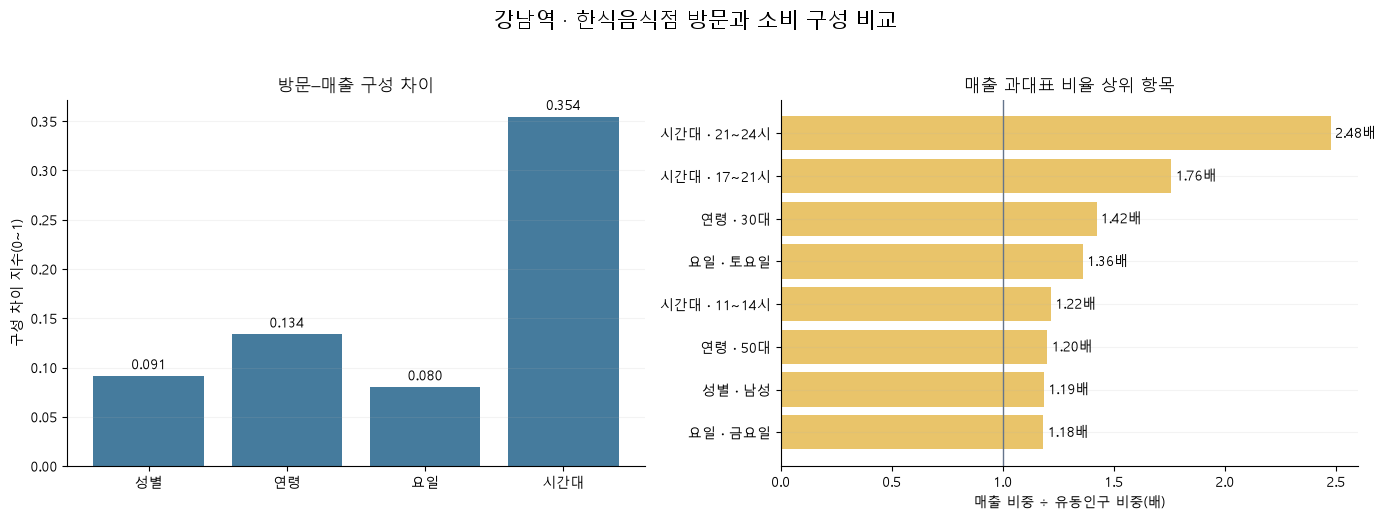

### 3단계 해석
- **성장 관계:** 수요–점포 성장 격차는 **-4.5%p**로, 전년 동기 대비 **점포 수가 유동인구보다 빠르게 증가**했다.
- **구성 차이:** 방문과 매출 구성의 차이는 **시간대**에서 가장 크고(T=0.354), **요일**에서 가장 작다(T=0.080).
- **상대적으로 높은 매출 비중:** **시간대 · 21~24시**의 매출 과대표 비율이 **2.48배**로 가장 높다.
- **자료 범위:** 매출액 구성비 커버리지는 구성 기준별 최소 **81.8%**다.

> 이 결과는 방문자와 매출의 집계 구성 차이를 보여준다. 동일인이 방문 후 구매했는지는 식별할 수 없으므로 실제 구매 전환율로 해석하지 않는다.

In [11]:
growth_gap_df = pd.DataFrame([
    ("유동인구 전년 동기 증감률", selected_commercial_row["유동인구_전년동기_증감률"], "%"),
    ("점포 수 전년 동기 증감률", selected_commercial_row["점포_전년동기_증감률"], "%"),
    ("수요–점포 성장 격차", selected_commercial_row["수요_점포_전년동기_증감률_차이"], "%p"),
], columns=["지표", "값", "단위"])
ratio_result_df = top_ratio_df[["구성 기준", "구성_명", "매출_금액_비중", "유동인구_비중", "매출_유동인구_비중_비율"]].copy()
ratio_result_df[["매출_금액_비중", "유동인구_비중"]] *= 100
ratio_result_df.columns = ["구성 기준", "구성 항목", "매출 비중(%)", "유동인구 비중(%)", "매출 과대표 비율"]

display(Markdown("### 수치 결과"))
display(growth_gap_df.style.format({"값": "{:,.1f}"}))
display(composition_result_df.style.format({"구성 차이 지수": "{:.3f}", "매출액 구성비 커버리지(%)": "{:.1f}"}))
display(Markdown("#### 매출 과대표 비율 상위 항목"))
display(ratio_result_df.style.format({"매출 비중(%)": "{:.1f}", "유동인구 비중(%)": "{:.1f}", "매출 과대표 비율": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
distance_bars = axes[0].bar(distance_df["구성 기준"], distance_df["구성 차이 지수"], color="#457B9D")
axes[0].bar_label(distance_bars, fmt="%.3f", padding=3)
axes[0].set(title="방문–매출 구성 차이", ylabel="구성 차이 지수(0~1)")

plot_ratio_df = ratio_result_df.sort_values("매출 과대표 비율")
ratio_labels = plot_ratio_df["구성 기준"] + " · " + plot_ratio_df["구성 항목"]
ratio_bars = axes[1].barh(ratio_labels, plot_ratio_df["매출 과대표 비율"], color="#E9C46A")
axes[1].bar_label(ratio_bars, fmt="%.2f배", padding=3)
axes[1].axvline(1, color="#64748B", linewidth=1)
axes[1].set(title="매출 과대표 비율 상위 항목", xlabel="매출 비중 ÷ 유동인구 비중(배)")
for ax in axes:
    ax.grid(axis="y", alpha=0.15)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"{selected_trade_area} · {selected_industry} 방문과 소비 구성 비교", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

growth_gap = selected_commercial_row["수요_점포_전년동기_증감률_차이"]
gap_interpretation = "유동인구가 점포 수보다 빠르게 증가" if growth_gap >= 0 else "점포 수가 유동인구보다 빠르게 증가"
largest_distance = distance_df.loc[distance_df["구성 차이 지수"].idxmax()]
smallest_distance = distance_df.loc[distance_df["구성 차이 지수"].idxmin()]
top_ratio = ratio_result_df.iloc[0]
coverage_min = composition_result_df["매출액 구성비 커버리지(%)"].min()
display(Markdown(
    f"""### 3단계 해석
- **성장 관계:** 수요–점포 성장 격차는 **{growth_gap:+.1f}%p**로, 전년 동기 대비 **{gap_interpretation}**했다.
- **구성 차이:** 방문과 매출 구성의 차이는 **{largest_distance['구성 기준']}**에서 가장 크고(T={largest_distance['구성 차이 지수']:.3f}), **{smallest_distance['구성 기준']}**에서 가장 작다(T={smallest_distance['구성 차이 지수']:.3f}).
- **상대적으로 높은 매출 비중:** **{top_ratio['구성 기준']} · {top_ratio['구성 항목']}**의 매출 과대표 비율이 **{top_ratio['매출 과대표 비율']:.2f}배**로 가장 높다.
- **자료 범위:** 매출액 구성비 커버리지는 구성 기준별 최소 **{coverage_min:.1f}%**다.

> 이 결과는 방문자와 매출의 집계 구성 차이를 보여준다. 동일인이 방문 후 구매했는지는 식별할 수 없으므로 실제 구매 전환율로 해석하지 않는다."""
))
